In [11]:
import os
from pathlib import Path
import pandas as pd
from constants import output_dir, blues, reds, font_prop
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy
from scipy.stats import gaussian_kde

# NC 

## Length

In [12]:
data_dir = "/Users/zhoukuangqi/Desktop/pepbenchmark/statistic_ppi_nc"

color = blues[2]
edge_color = blues[-2]
vline_color = reds[-3]
dataset_names = [each for each in os.listdir(data_dir) if each.startswith("nc-")]

In [13]:
os.makedirs(save_dir := (output_dir / Path("nc_ppi_0922")), exist_ok=True)

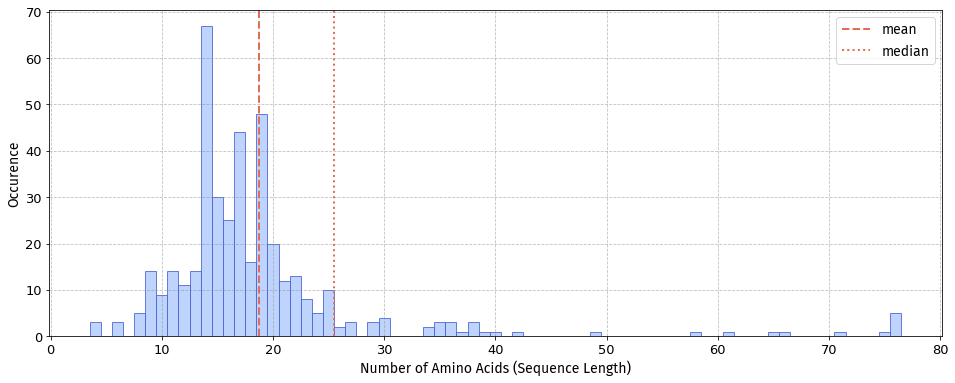

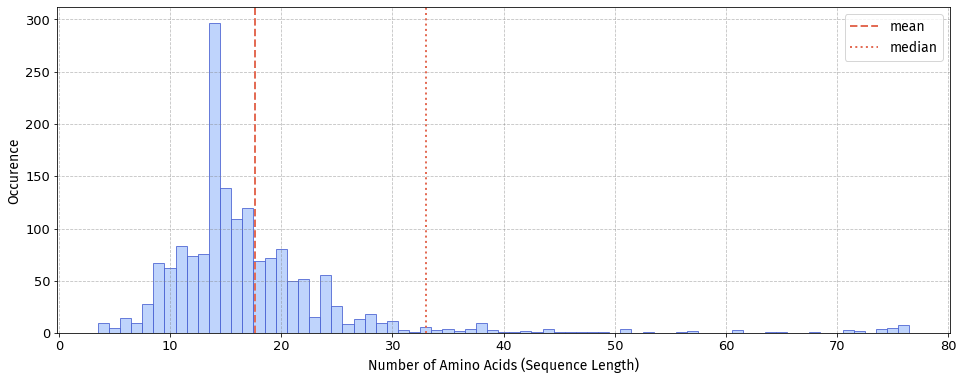

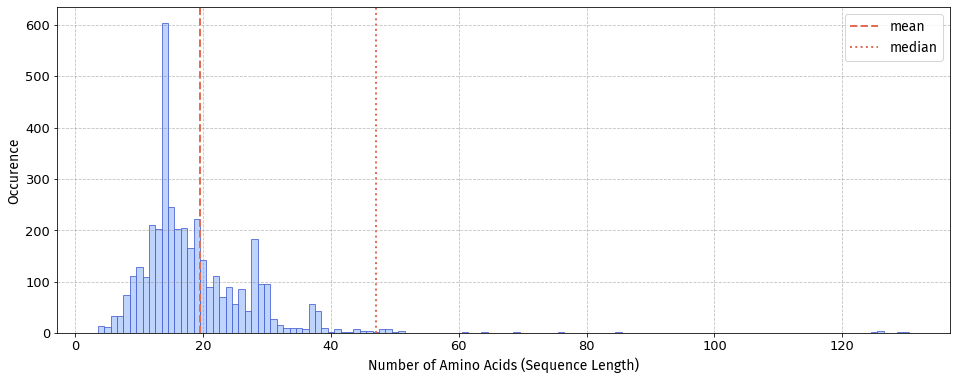

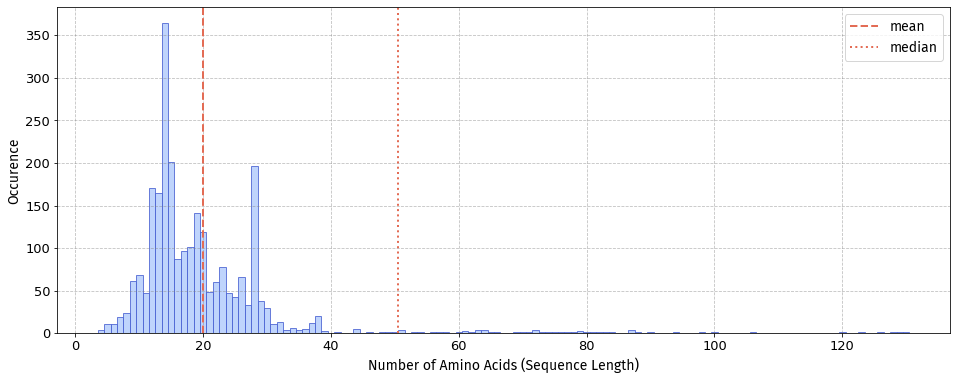

In [14]:
for dataset_name in dataset_names:
    data_info = pd.read_csv(data_dir/Path(dataset_name)/ Path("all.csv"))

    lengths = data_info['FASTA'].apply(lambda x: len(x)).values
    
    len_values, counts = np.unique(lengths, return_counts=True)
    mean = np.mean(lengths)
    med = np.median(len_values)

    if len(counts) > 10:
        plt.figure(figsize=(16, 6))
        plt.bar(
            len_values, 
            counts, 
            color=color, 
            width=1.0, 
            align='center',
            edgecolor=edge_color,
            alpha=0.8
        )
    else:
        plt.figure(figsize=(6, 6))
        plt.bar(
            len_values, 
            counts, 
            color=color, 
            width=1.0, 
            align='center',
            edgecolor=edge_color,
            alpha=0.8
        )
        int_med = int(med)
        
        x_min, x_max = max(0, int_med-10), min(int_med+10, 22)
        plt.xlim(x_min, x_max)
        ticks = np.arange(x_min, x_max, 2)
    
        new_labels = [int(t) for t in ticks]
        plt.xticks(ticks, new_labels)

    plt.axvline(x=mean, color=vline_color, linestyle='--', linewidth=2, label="mean")
    plt.axvline(x=med, color=vline_color, linestyle=':', linewidth=2, label="median")

    plt.xlabel("Number of Amino Acids (Sequence Length)", fontsize=14, fontproperties=font_prop,)
    plt.ylabel("Occurence", fontsize=14, fontproperties=font_prop,)
    plt.xticks(fontsize=13)
    plt.yticks(fontsize=13)

    legend_font_prop = deepcopy(font_prop)
    legend_font_prop.set_size(14)
    plt.legend(fontsize=20, prop=legend_font_prop)
    plt.grid(True, linestyle='--', color='gray', alpha=0.5)

    plt.savefig(
        save_dir / Path(f"len_{dataset_name}.png"), 
        dpi=200, 
        bbox_inches="tight", 
        transparent=True
    )

## AA

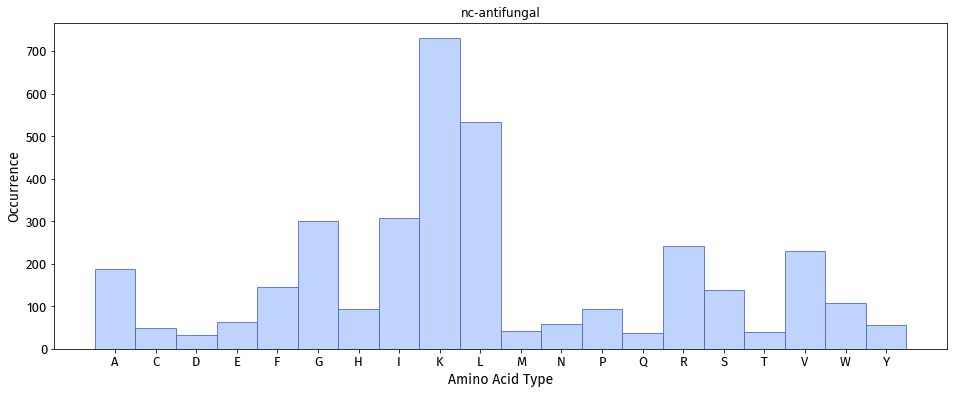

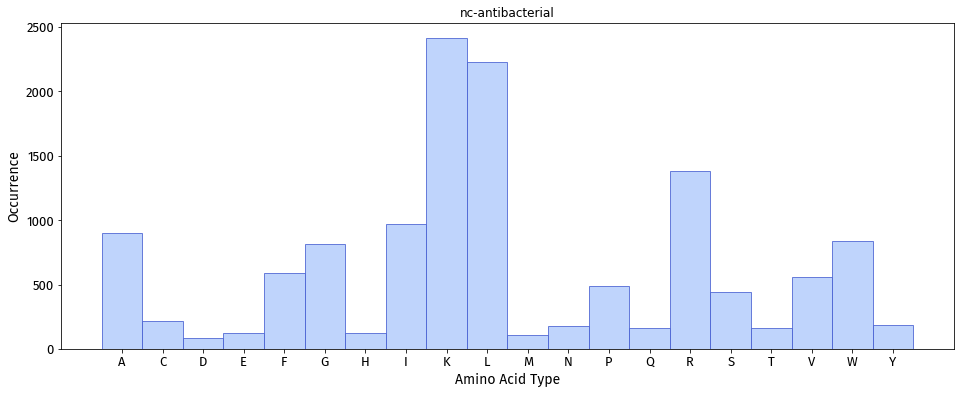

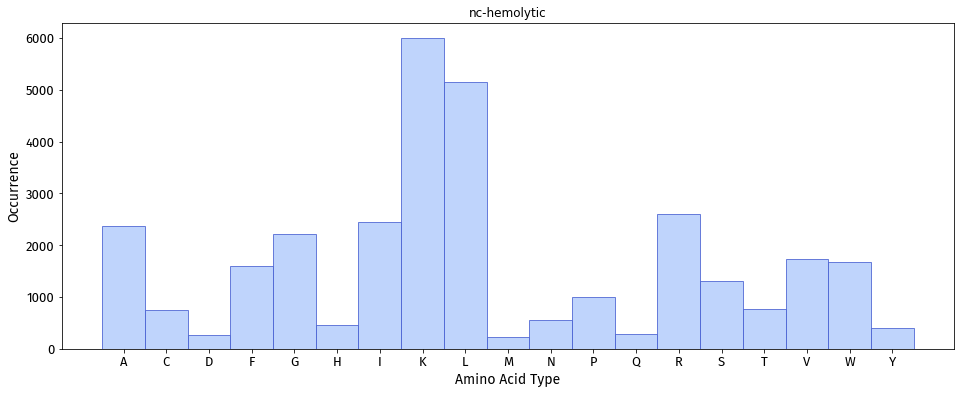

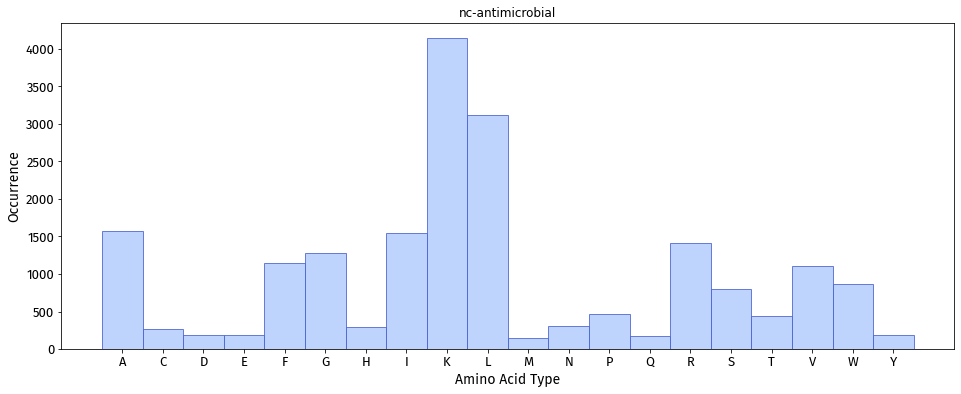

In [15]:
for dataset_name in dataset_names:
    data_info = pd.read_csv(data_dir/Path(dataset_name)/ Path("monomer_frequency_analysis.csv"))
        
    aa_to_frec = {row['Monomer']: row['Frequency'] for _, row in data_info.iterrows() if row['Type'] == "Standard"}
    
    aa_types = list(sorted(aa_to_frec.keys()))
    counts = [aa_to_frec[aa] for aa in aa_types]

    x = np.arange(len(aa_types))

    plt.figure(figsize=(16, 6))
    
    plt.bar(
        x, 
        counts, 
        color=color, 
        width=1.0, 
        align='center',
        edgecolor=edge_color,
        alpha=0.8
    )

    plt.xticks(x, aa_types)

    plt.xlabel("Amino Acid Type", fontsize=14, fontproperties=font_prop,)
    plt.ylabel("Occurrence", fontsize=14, fontproperties=font_prop,)
    plt.xticks(fontsize=13, fontproperties=font_prop)
    plt.yticks(fontsize=13, fontproperties=font_prop)

    plt.savefig(
        save_dir / Path(f"aa_{dataset_name}.png"), 
        dpi=200, 
        bbox_inches="tight", 
        transparent=True
    )

    plt.title(dataset_name)

## NCAA

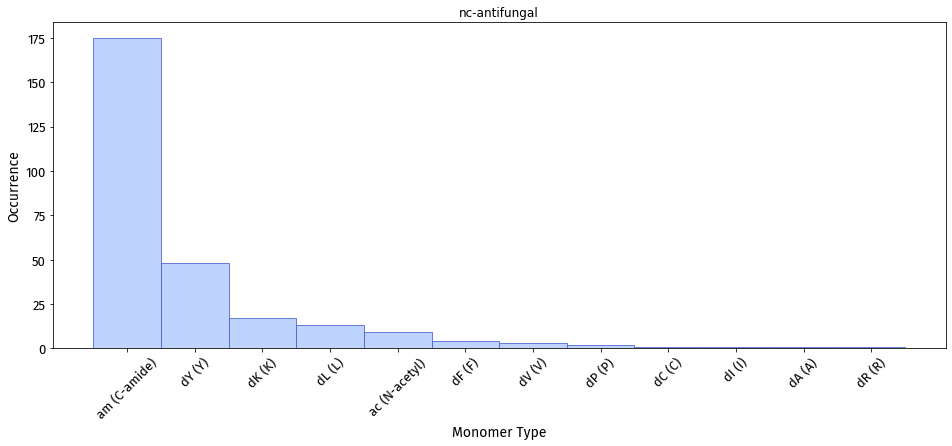

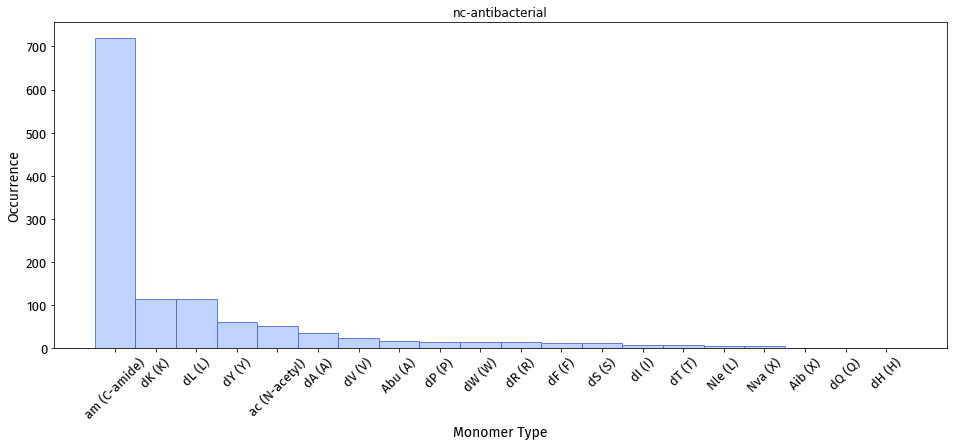

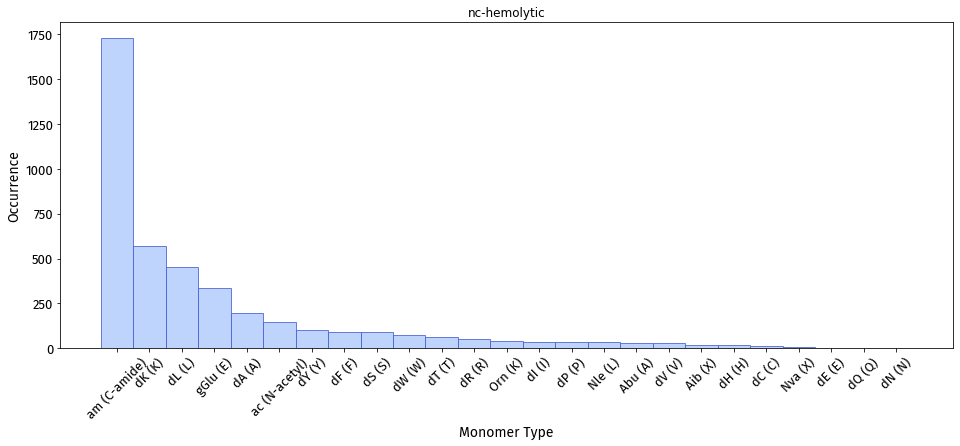

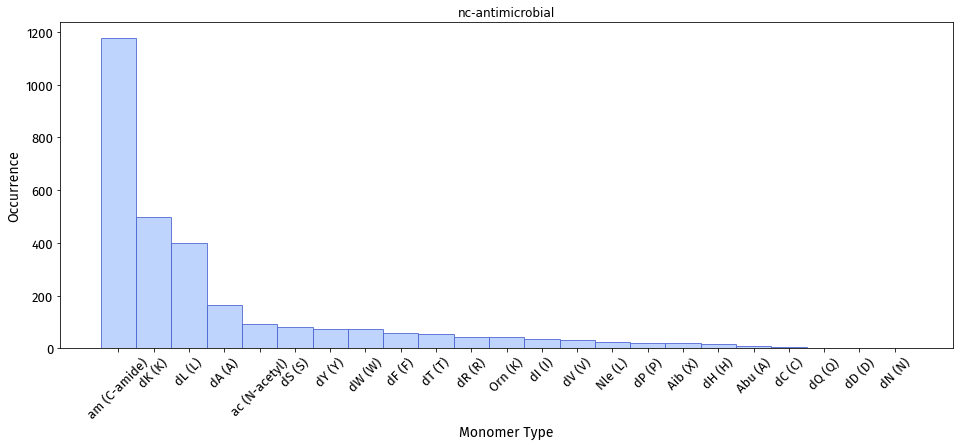

In [16]:
for dataset_name in dataset_names:
    data_info = pd.read_csv(data_dir/Path(dataset_name)/ Path("monomer_frequency_analysis.csv"))
        
    aa_to_frec = {row['Monomer']: row['Frequency'] for _, row in data_info.iterrows() if row['Type'] == "Non-standard"}
    
    aa_types = list(sorted(aa_to_frec.keys(), key=lambda k: aa_to_frec[k], reverse=True))
    counts = [aa_to_frec[aa] for aa in aa_types]

    origin_aa = data_info[data_info['Type']=='Non-standard'].groupby(
        by="Monomer"
    ).agg(
        {"Natural_Analog": lambda x: ", ".join(x)}
        ).reset_index(drop=False).set_index("Monomer")["Natural_Analog"].to_dict()

    x = np.arange(len(aa_types))

    plt.figure(figsize=(16, 6))
    
    plt.bar(
        x, 
        counts, 
        color=color, 
        width=1.0, 
        align='center',
        edgecolor=edge_color,
        alpha=0.8
    )

    plt.xticks(x, [" ".join([aa_type, f"({origin_aa[aa_type]})"]) for aa_type in aa_types])

    plt.xlabel("Monomer Type", fontsize=14, fontproperties=font_prop,)
    plt.ylabel("Occurrence", fontsize=14, fontproperties=font_prop,)
    plt.xticks(fontsize=13, fontproperties=font_prop, rotation=45)
    plt.yticks(fontsize=13, fontproperties=font_prop)

    plt.savefig(
        save_dir / Path(f"ncaa_{dataset_name}.png"), 
        dpi=200, 
        bbox_inches="tight", 
        transparent=True
    )

    plt.title(dataset_name)

# PPI

## length

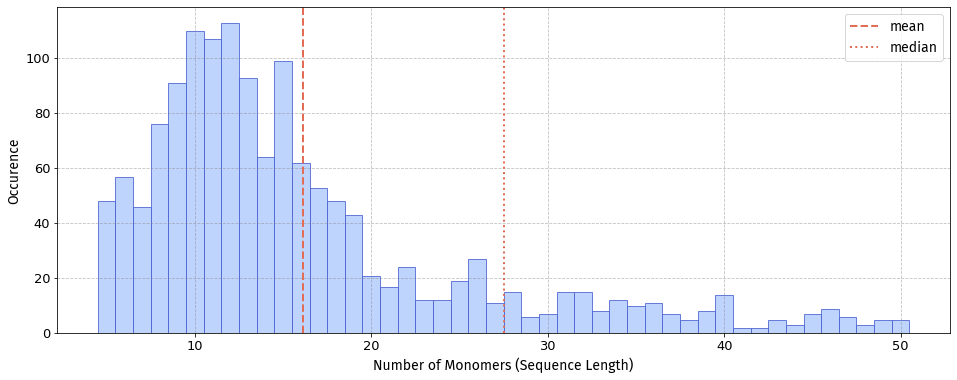

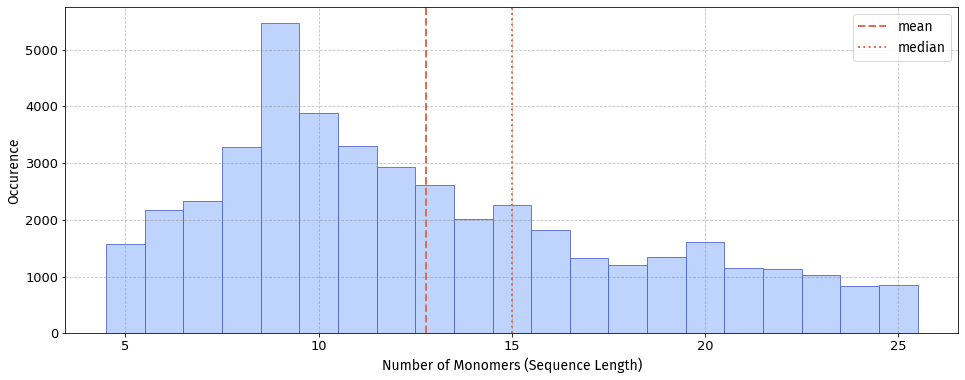

In [17]:
dataset_names = [each for each in os.listdir(data_dir) if each.startswith("PpI")]

for dataset_name in dataset_names:
    data_info = pd.read_csv(data_dir/Path(dataset_name)/ Path("pep_fasta.csv"))

    lengths = data_info['feature'].apply(lambda x: len(x)).values
    
    len_values, counts = np.unique(lengths, return_counts=True)
    mean = np.mean(lengths)
    med = np.median(len_values)

    if len(counts) > 10:
        plt.figure(figsize=(16, 6))
        plt.bar(
            len_values, 
            counts, 
            color=color, 
            width=1.0, 
            align='center',
            edgecolor=edge_color,
            alpha=0.8
        )
    else:
        plt.figure(figsize=(6, 6))
        plt.bar(
            len_values, 
            counts, 
            color=color, 
            width=1.0, 
            align='center',
            edgecolor=edge_color,
            alpha=0.8
        )
        int_med = int(med)
        
        x_min, x_max = max(0, int_med-10), min(int_med+10, 22)
        plt.xlim(x_min, x_max)
        ticks = np.arange(x_min, x_max, 2)
    
        new_labels = [int(t) for t in ticks]
        plt.xticks(ticks, new_labels)

    plt.axvline(x=mean, color=vline_color, linestyle='--', linewidth=2, label="mean")
    plt.axvline(x=med, color=vline_color, linestyle=':', linewidth=2, label="median")

    plt.xlabel("Number of Monomers (Sequence Length)", fontsize=14, fontproperties=font_prop,)
    plt.ylabel("Occurence", fontsize=14, fontproperties=font_prop,)
    plt.xticks(fontsize=13)
    plt.yticks(fontsize=13)

    legend_font_prop = deepcopy(font_prop)
    legend_font_prop.set_size(14)
    plt.legend(fontsize=20, prop=legend_font_prop)
    plt.grid(True, linestyle='--', color='gray', alpha=0.5)

    plt.savefig(
        save_dir / Path(f"len_{dataset_name}.png"), 
        dpi=200, 
        bbox_inches="tight", 
        transparent=True
    )

## AA

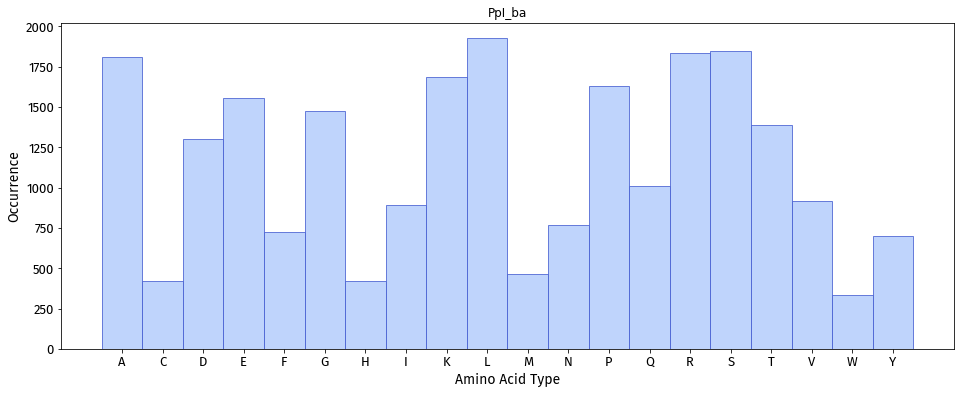

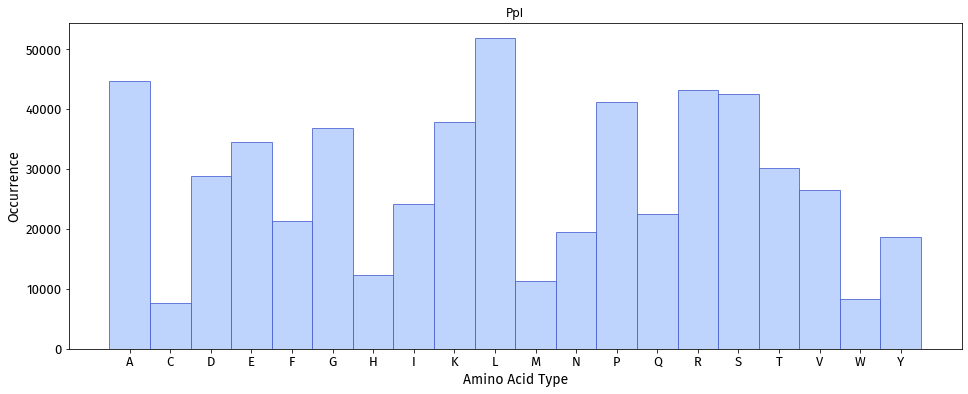

In [18]:
for dataset_name in dataset_names:
    data_info = pd.read_csv(data_dir/Path(dataset_name)/ Path("amino_acid_frequency.csv"))
        
    aa_to_frec = data_info.transpose().rename({0: "freq"}, axis=1).to_dict()['freq']
    
    aa_types = list(sorted(aa_to_frec.keys()))
    counts = [aa_to_frec[aa] for aa in aa_types]

    x = np.arange(len(aa_types))

    plt.figure(figsize=(16, 6))
    
    plt.bar(
        x, 
        counts, 
        color=color, 
        width=1.0, 
        align='center',
        edgecolor=edge_color,
        alpha=0.8
    )

    plt.xticks(x, aa_types)

    plt.xlabel("Amino Acid Type", fontsize=14, fontproperties=font_prop,)
    plt.ylabel("Occurrence", fontsize=14, fontproperties=font_prop,)
    plt.xticks(fontsize=13, fontproperties=font_prop)
    plt.yticks(fontsize=13, fontproperties=font_prop)

    plt.savefig(
        save_dir / Path(f"aa_{dataset_name}.png"), 
        dpi=200, 
        bbox_inches="tight", 
        transparent=True
    )

    plt.title(dataset_name)

In [19]:
data_info.transpose().rename({0: "freq"}, axis=1).to_dict()['freq']

{'A': 44787,
 'R': 43272,
 'N': 19574,
 'D': 28899,
 'C': 7619,
 'Q': 22496,
 'E': 34606,
 'G': 36867,
 'H': 12293,
 'I': 24151,
 'L': 51812,
 'K': 37828,
 'M': 11361,
 'F': 21350,
 'P': 41246,
 'S': 42537,
 'T': 30130,
 'W': 8382,
 'Y': 18716,
 'V': 26546}

## label

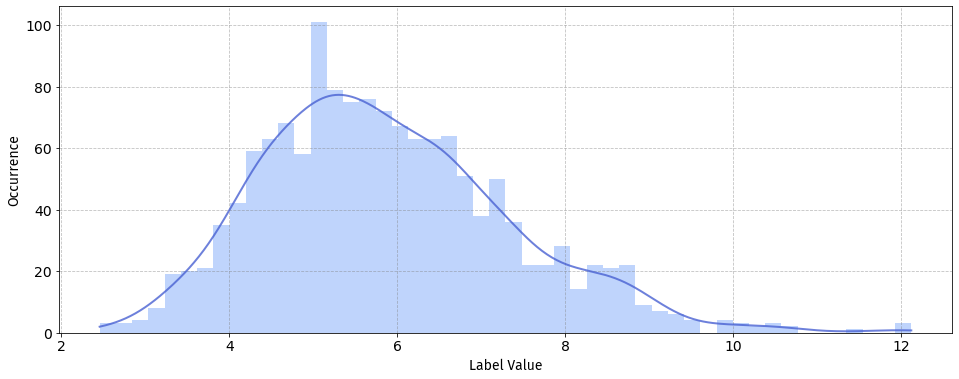

In [20]:
dataset_name = "PpI_ba"
data_info = pd.read_csv(data_dir/Path(dataset_name)/ Path("label.csv"))
labels = data_info['feature'].values
p_label = gaussian_kde(labels)

plt.figure(figsize=(16, 6))

counts, bins, _ = plt.hist(
    labels, 
    bins=50, 
    alpha=0.8, 
    color=color, 
    density=False
)

bin_width = bins[1] - bins[0]
y_min, y_max = labels.min(), labels.max()
x = np.linspace(y_min, y_max, 500)
y = p_label(x) * len(labels) * bin_width

plt.plot(
    x,
    y,
    color=edge_color,
    linewidth=2,
    alpha=0.8,
)

plt.xlabel("Label Value", fontsize=14, fontproperties=font_prop,)
plt.ylabel("Occurrence", fontsize=14, fontproperties=font_prop,)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True, linestyle='--', color='gray', alpha=0.5)
plt.savefig(
    save_dir / Path(f"label_{dataset_name}.png"), 
    dpi=200, 
    bbox_inches="tight", 
    transparent=True
)